# Generative Model

## *Nina Haide*

## Introduction

This project implements a generative AI system for career guidance in the AI job
market. The system takes a user's resume or skill profile as input, matches it
against the five AI job market personas discovered in Project 4 and generates
a personalised role recommendation explaining the fit, highlighting relevant
skills, and - where the match is weak - suggesting a development pathway into
the AI industry.

The generative model is GPT-2, a pre-trained Transformer decoder implemented
in PyTorch via HuggingFace. Rather than fine-tuning on synthetic labels, GPT-2
is used as a prompted generator: a structured prompt is constructed from the
user's extracted skill profile and similarity scores against the five archetype
centroids and GPT-2 generates a natural language recommendation from that
prompt. This approach keeps the generative pipeline grounded in real data while
avoiding the introduction of AI-generated training content.

The resume dataset used for input examples is sourced from Kaggle
(snehaanbhawal/resume-dataset) - 2,484 real resumes scraped from livecareer.com
across 24 job categories. Skill extraction uses the 50-skill taxonomy developed
in Project 3, and archetype similarity is computed against the DistilBERT
centroids from Project 4, creating a direct continuation of the analytical
pipeline built across the full course.

## Data Set

The resume dataset is sourced from Kaggle (snehaanbhawal/resume-dataset) and
contains 2,484 real resumes scraped from livecareer.com across 24 job categories
including Information Technology, Engineering, Consulting, Finance and Healthcare.
The data was collected approximately five years ago and while it does not reflect
the most current AI-specific role landscape, it represents traditional resume
structure and content well - covering the kind of skills, experience descriptions
and professional language that applicants across industries consistently use.
The dataset requires thorough preprocessing before use: resume text contains
HTML artefacts, special characters, URLs, contact information and OCR noise
from the original PDF scraping process that must be cleaned before meaningful
skill extraction can be performed. Only the `Resume_str` and `Category` columns
are used in this project - the HTML version is discarded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
df = pd.read_csv("Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

Data types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object


Category distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


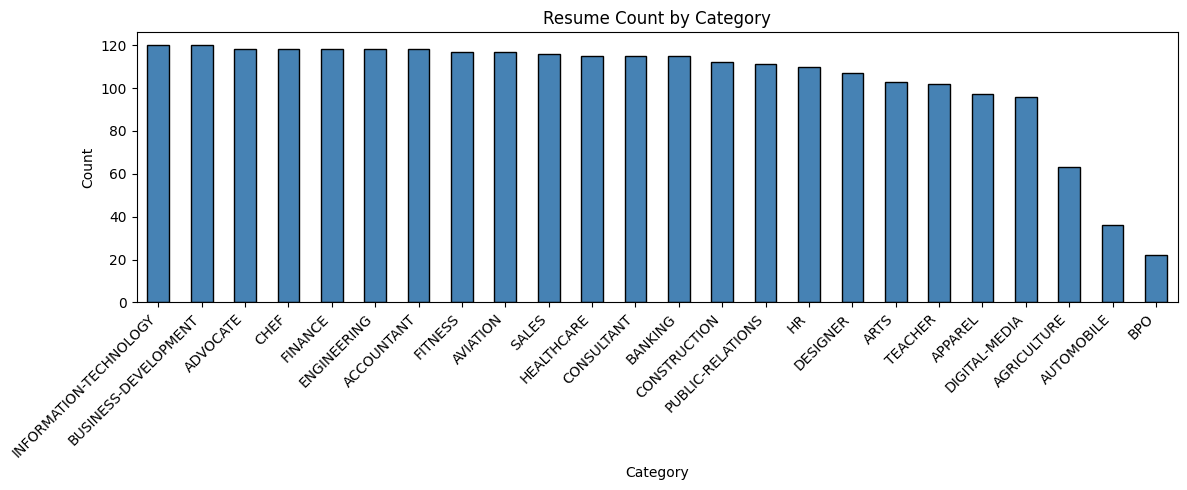

In [5]:
print("Category distribution:")
print(df["Category"].value_counts())

plt.figure(figsize=(12, 5))
df["Category"].value_counts().plot(kind="bar", edgecolor="black", color="steelblue")
plt.title("Resume Count by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("viz_category_distribution.png", dpi=150)
plt.show()

In [6]:
print("Sample resumes:\n")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"Category : {row['Category']}")
    print(f"Preview  : {str(row['Resume_str'])[:400]}...")
    print("-" * 60)

Sample resumes:

Category : TEACHER
Preview  :            Kpandipou    Koffi         Summary      Compassionate teaching professional delivering exemplary support and assistance to teachers and students. Display exceptional Communication and problem solving skills.  Experience in office administration and public speaking. Attentive and adaptable, skilled in management of classroom operations. Effective in leveraging student feedback to create ...
------------------------------------------------------------
Category : DIGITAL-MEDIA
Preview  :          DIRECTOR OF DIGITAL TRANSFORMATION       Executive Profile     Digital and print media professional  and consultant with a strong vision to develop new projects and specialist in business development. Strong management skills and leading teams. Result oriented. Passionate and experienced in product and audience development, analytic tools, emerging technologies and their applications in t...
------------------------------------------------

Resume text length stats:
count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: text_length, dtype: float64


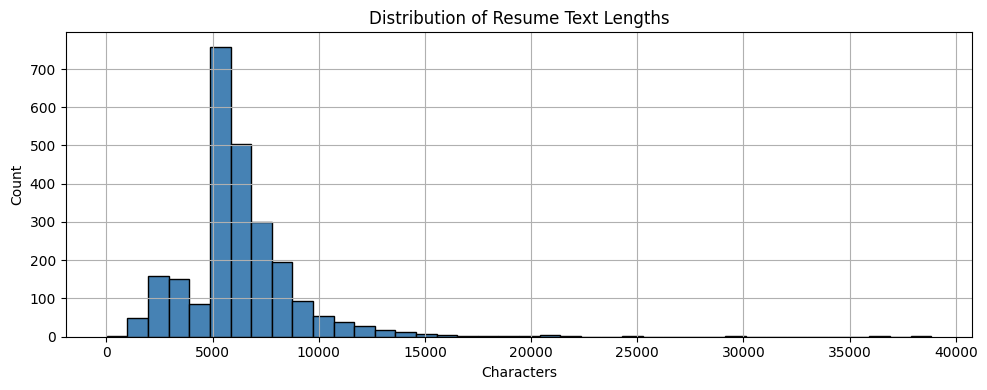

In [9]:
df["text_length"] = df["Resume_str"].str.len()

print("Resume text length stats:")
print(df["text_length"].describe())

plt.figure(figsize=(10, 4))
df["text_length"].hist(bins=40, edgecolor="black", color="steelblue")
plt.title("Distribution of Resume Text Lengths")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("viz_resume_lengths.png", dpi=150)
plt.show()

In [10]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Empty resume texts: {(df['Resume_str'].str.strip() == '').sum()}")

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
text_length    0
dtype: int64

Duplicate rows: 0
Empty resume texts: 1


In [11]:
print("\nSample raw text showing noise (first 800 chars of one resume):")
print(df["Resume_str"].iloc[0][:800])


Sample raw text showing noise (first 800 chars of one resume):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as   


The dataset contains 2,484 resumes across 24 categories with no missing values
and minimal duplicates. Resume texts vary significantly in length - from a few
hundred to several thousand characters - reflecting differences in formatting
and verbosity across candidates. Raw text contains substantial noise including
HTML tags, URLs, email addresses, phone numbers, special characters and
repeated whitespace inherited from the PDF scraping process.

In [13]:
print(df["Category"].unique())

<StringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str


In [14]:
tech_categories = ["INFORMATION-TECHNOLOGY", "ENGINEERING", "CONSULTANT"]
df_tech = df[df["Category"].isin(tech_categories)].copy()

print(f"Full dataset  : {len(df)} resumes")
print(f"Tech-relevant : {len(df_tech)} resumes")
print(f"\nTech category counts:")
print(df_tech["Category"].value_counts())

Full dataset  : 2484 resumes
Tech-relevant : 353 resumes

Tech category counts:
Category
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
CONSULTANT                115
Name: count, dtype: int64


While the dataset contains 24 job categories, only three - INFORMATION-TECHNOLOGY,
ENGINEERING and CONSULTANT - were initially considered tech-relevant. However,
categories such as AUTOMOBILE, AVIATION and BANKING may equally contain strong
engineering or analytical skill profiles that overlap with AI archetypes and
pre-filtering by label would exclude these candidates unfairly. Fit is therefore
determined entirely by skill extraction and similarity scoring at runtime rather
than assumed from the category name.

In [ ]:
pip freeze > requirements.txt